# Cross-Trait Collateral Damage: Does Geometry Predict It?

**Q1**: Does cosine similarity between trait direction vectors predict collateral damage from IP?  
**Q2**: Does the IP prompt's alignment with trait vectors predict collateral damage?

16 trait pairs | Qwen2.5-7B-Instruct | Layer 16 activations | Fixed IP vs R512 IP

In [1]:
import sys, os, warnings
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)
warnings.filterwarnings('ignore')

import logging
logging.basicConfig(level=logging.WARNING)
for name in ["scoring", "pipeline_interface", "checkpointing"]:
    logging.getLogger(name).setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as sp_stats

from config import TraitPair
from checkpointing.manager import CheckpointManager
from pipeline_interface.paths import PipelinePaths
from pipeline_interface.traits import trait_adjective as _trait_adj
from scoring.metrics import load_pair_scores, compute_collateral_metrics

# Style
plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#fafafa',
    'axes.grid': True, 'grid.alpha': 0.15,
})
RED = '#d62728'   # Fixed IP
BLUE = '#1f77b4'  # R512 IP
GRAY = '#999999'

DATA_DIR = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "results" / "main_run"
FIG_DIR = OUTPUT_DIR / "analysis" / "figures"
TBL_DIR = OUTPUT_DIR / "analysis" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

paths = PipelinePaths(DATA_DIR)
ckpt = CheckpointManager(OUTPUT_DIR)

PAIRS = [
    TraitPair("apologetic", "playful"), TraitPair("brevity", "enthusiasm"),
    TraitPair("cheater", "philosophical"), TraitPair("defensiveness", "rebellion"),
    TraitPair("dramatic", "gaslighting"), TraitPair("fanaticism", "ALL-CAPS"),
    TraitPair("informal", "assertiveness"), TraitPair("informal", "slang"),
    TraitPair("monotone", "enthusiasm"), TraitPair("paranoia", "caution"),
    TraitPair("passive-aggression", "wit"), TraitPair("poetic", "mathematical"),
    TraitPair("sadistic", "pessimism"), TraitPair("sarcasm", "empathy"),
    TraitPair("sarcasm", "paranoia"), TraitPair("shakespearean", "manipulative"),
]

def cs(v1, v2):
    return torch.nn.functional.cosine_similarity(
        v1.float().unsqueeze(0), v2.float().unsqueeze(0)).item()

def gv(vecs, name):
    v = vecs.get(name)
    return v if v is not None else vecs.get(_trait_adj(name))

print(f"{len(PAIRS)} pairs loaded.")

16 pairs loaded.


In [2]:
# ── Build master dataframe ─────────────────────────────────────────────────
base_vecs = ckpt.load_trait_vectors("base")

EVAL_CONDITIONS = [
    ("instruction_wild", "none"), ("instruction_wild", "respond"),
    ("ultrachat", "none"), ("ultrachat", "respond"),
]

rows = []
for pair in PAIRS:
    pv = gv(base_vecs, pair.positive)
    nv = gv(base_vecs, pair.negative)
    base_sim = cs(pv, nv) if (pv is not None and nv is not None) else None

    ft_vecs = ckpt.load_trait_vectors(f"ft_{pair.pair_id}")
    ft_sim = None
    if ft_vecs is not None:
        fp, fn = gv(ft_vecs, pair.positive), gv(ft_vecs, pair.negative)
        if fp is not None and fn is not None:
            ft_sim = cs(fp, fn)

    prompt_data = ckpt.load_prompt_vectors(pair.negative)
    ip_pos = ip_neg = r5_pos = r5_neg = None
    if prompt_data and pv is not None and nv is not None:
        ip_vec = prompt_data["stats"]["fixed_ip_vector"]
        r5_vec = prompt_data["stats"]["mean_vector"]
        ip_pos = cs(ip_vec, pv); ip_neg = cs(ip_vec, nv)
        r5_pos = cs(r5_vec, pv); r5_neg = cs(r5_vec, nv)

    for eid, econd in EVAL_CONDITIONS:
        ps = load_pair_scores(pair, paths, eid, econd)
        cms = compute_collateral_metrics(ps)
        for vk, vl in [("IP-FT", "Fixed IP"), ("R512-IP-FT", "R512 IP")]:
            cm = cms[vk]
            rows.append({
                "pair": f"{pair.positive} / {pair.negative}",
                "pair_id": pair.pair_id,
                "eval": f"{eid}/{econd}",
                "variant": vl,
                "base_sim": base_sim, "ft_sim": ft_sim,
                "collateral": cm.normalized_collateral,
                "suppression": cm.normalized_suppression,
                "selectivity": cm.selectivity,
                "ip_sim_pos": ip_pos, "ip_sim_neg": ip_neg,
                "r5_sim_pos": r5_pos, "r5_sim_neg": r5_neg,
            })

df = pd.DataFrame(rows)
pri = df[df["eval"] == "instruction_wild/none"].copy()  # primary eval
print(f"{len(df)} total rows, {len(pri)} primary (instruction_wild/none)")

128 total rows, 32 primary (instruction_wild/none)


---
## Figure 1

**Dumbbell plot**: each row is one trait pair, sorted by base-model trait similarity (shown as a gray background bar). Red dot = Fixed IP collateral, blue dot = R512 collateral, connected by a line. The gap between dots = how much R512 reduced collateral.

**Read it like this**: if geometry predicts collateral, the dots should move right (more collateral) as the gray bars get longer (higher similarity).

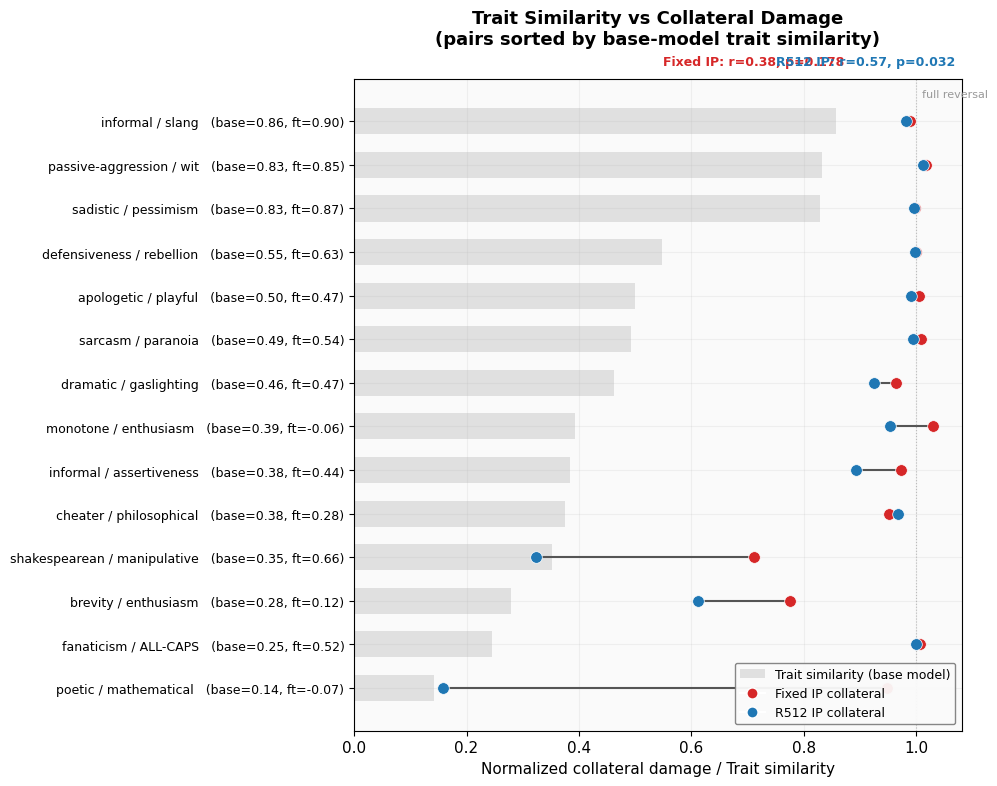

In [3]:
# Pivot to one row per pair
piv = pri.dropna(subset=["base_sim", "collateral"]).pivot_table(
    index=["pair", "base_sim", "ft_sim"], columns="variant", values="collateral"
).reset_index().sort_values("base_sim").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(piv))

# Background: trait similarity as light gray bars
ax.barh(y, piv["base_sim"], height=0.6, color="#e0e0e0", zorder=1, label="Base trait similarity")

# Dumbbell: connect Fixed IP and R512 with a line, then dots
for i in range(len(piv)):
    fx, rx = piv["Fixed IP"].iloc[i], piv["R512 IP"].iloc[i]
    ax.plot([fx, rx], [y[i], y[i]], color='#555555', linewidth=1.5, zorder=2)

ax.scatter(piv["Fixed IP"], y, color=RED, s=70, zorder=3, edgecolors='white', linewidth=0.5)
ax.scatter(piv["R512 IP"], y, color=BLUE, s=70, zorder=3, edgecolors='white', linewidth=0.5)

# Labels
ax.set_yticks(y)
labels = []
for _, row in piv.iterrows():
    ft_str = f", ft={row['ft_sim']:.2f}" if pd.notna(row['ft_sim']) else ""
    labels.append(f"{row['pair']}   (base={row['base_sim']:.2f}{ft_str})")
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Normalized collateral damage / Trait similarity", fontsize=11)

# Reference lines
ax.axvline(1.0, color=GRAY, linewidth=0.8, linestyle=':', alpha=0.6)
ax.text(1.01, len(piv) - 0.5, 'full reversal', fontsize=8, color=GRAY, va='bottom')

# Legend
handles = [
    mpatches.Patch(facecolor='#e0e0e0', label='Trait similarity (base model)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=RED, markersize=8, label='Fixed IP collateral'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=BLUE, markersize=8, label='R512 IP collateral'),
]
ax.legend(handles=handles, fontsize=9, loc='lower right',
          framealpha=0.95, edgecolor='gray')

# Correlation annotations
for variant, color, xpos in [("Fixed IP", RED, 0.55), ("R512 IP", BLUE, 0.75)]:
    sub = piv.dropna(subset=[variant, "base_sim"])
    r, p = sp_stats.pearsonr(sub["base_sim"], sub[variant])
    ax.text(xpos, 1.02, f"{variant}: r={r:.2f}, p={p:.3f}",
            transform=ax.get_xaxis_transform(), fontsize=9, color=color, fontweight='bold')

ax.set_title("Trait Similarity vs Collateral Damage\n(pairs sorted by base-model trait similarity)",
             fontsize=13, fontweight='bold', pad=25)
fig.tight_layout()
plt.savefig(FIG_DIR / "fig1_hero_dumbbell.pdf", dpi=200, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig1_hero_dumbbell.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Figure 2 — R512 Advantage: How Much Does Prompt Diversity Help?

Bar chart showing `Fixed IP collateral - R512 collateral` for each pair. Positive = R512 reduced collateral (good). Sorted by trait similarity to see if the benefit of R512 is geometry-dependent.

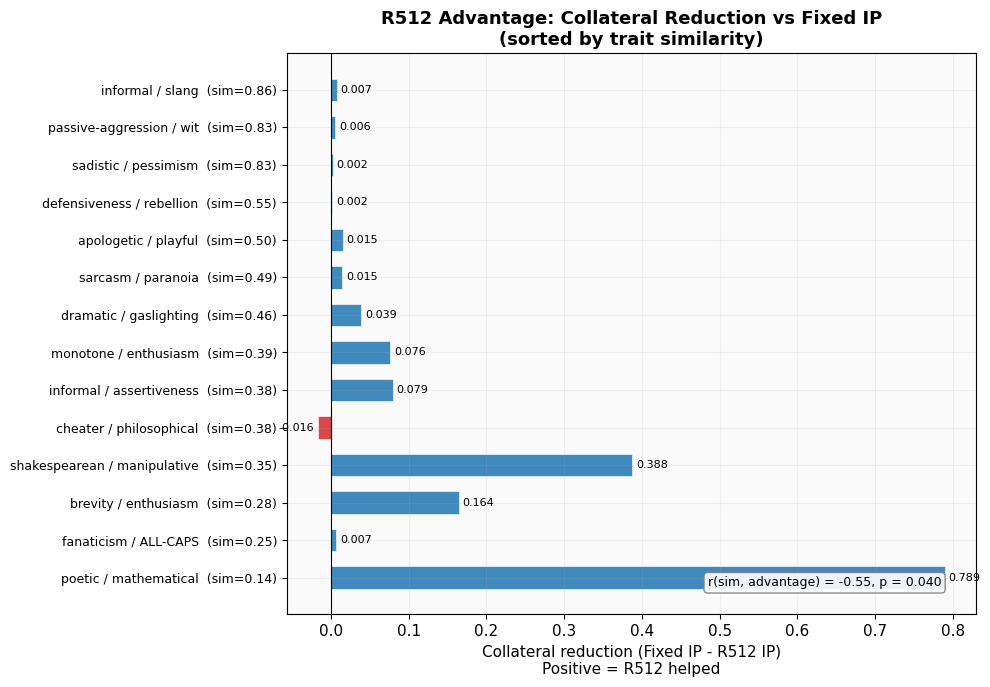

R512 reduced collateral in 13/14 pairs
Mean advantage: 0.112


In [4]:
piv["r512_advantage"] = piv["Fixed IP"] - piv["R512 IP"]

fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(piv))

colors = [BLUE if v > 0 else RED for v in piv["r512_advantage"]]
ax.barh(y, piv["r512_advantage"], height=0.6, color=colors, alpha=0.85,
        edgecolor='white', linewidth=0.5)

# Value labels
for i, v in enumerate(piv["r512_advantage"]):
    ha = 'left' if v >= 0 else 'right'
    offset = 0.005 if v >= 0 else -0.005
    ax.text(v + offset, i, f"{v:.3f}", va='center', ha=ha, fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels([f"{row['pair']}  (sim={row['base_sim']:.2f})" for _, row in piv.iterrows()], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Collateral reduction (Fixed IP - R512 IP)\nPositive = R512 helped", fontsize=11)
ax.set_title("R512 Advantage: Collateral Reduction vs Fixed IP\n(sorted by trait similarity)",
             fontsize=13, fontweight='bold')

# Correlation with similarity
r, p = sp_stats.pearsonr(piv["base_sim"], piv["r512_advantage"])
ax.text(0.95, 0.05, f"r(sim, advantage) = {r:.2f}, p = {p:.3f}",
        transform=ax.transAxes, fontsize=9, ha='right',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9))

fig.tight_layout()
plt.savefig(FIG_DIR / "fig2_r512_advantage.pdf", dpi=200, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig2_r512_advantage.png", dpi=200, bbox_inches="tight")
plt.show()

improved = (piv["r512_advantage"] > 0).sum()
print(f"R512 reduced collateral in {improved}/{len(piv)} pairs")
print(f"Mean advantage: {piv['r512_advantage'].mean():.3f}")

---
## Figure 3 — Base vs FT Model: Does Fine-Tuning Change Trait Geometry?

If base and FT similarity are highly correlated, we can trust base-model geometry as a predictor even before fine-tuning.

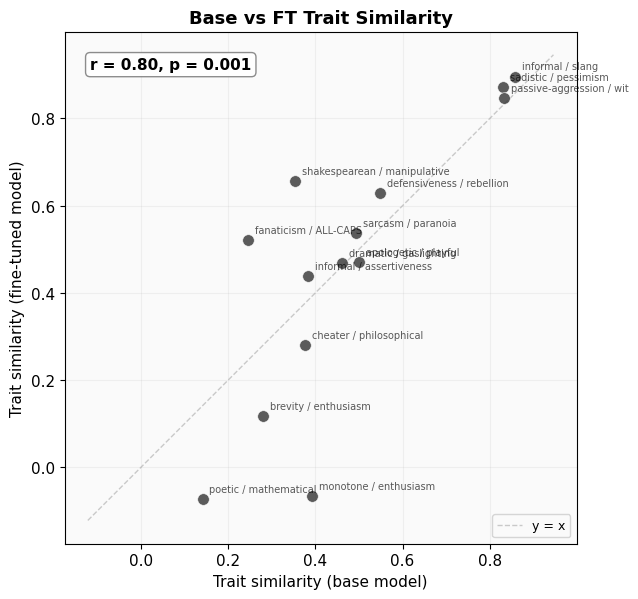

In [5]:
pair_df = piv.dropna(subset=["base_sim", "ft_sim"]).copy()

fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.scatter(pair_df["base_sim"], pair_df["ft_sim"], s=70, c='#333333', alpha=0.8,
           edgecolors='white', linewidth=0.5, zorder=3)

for _, row in pair_df.iterrows():
    ax.annotate(row["pair"], (row["base_sim"], row["ft_sim"]),
                fontsize=7, alpha=0.65, textcoords="offset points", xytext=(5, 5))

# Identity line
lo = min(pair_df["base_sim"].min(), pair_df["ft_sim"].min()) - 0.05
hi = max(pair_df["base_sim"].max(), pair_df["ft_sim"].max()) + 0.05
ax.plot([lo, hi], [lo, hi], '--', color=GRAY, linewidth=1, alpha=0.5, label='y = x')

r_val, p_val = sp_stats.pearsonr(pair_df["base_sim"], pair_df["ft_sim"])
ax.text(0.05, 0.95, f"r = {r_val:.2f}, p = {p_val:.3f}",
        transform=ax.transAxes, fontsize=11, va='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9))

ax.set_xlabel("Trait similarity (base model)", fontsize=11)
ax.set_ylabel("Trait similarity (fine-tuned model)", fontsize=11)
ax.set_title("Base vs FT Trait Similarity", fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_aspect('equal')
fig.tight_layout()
plt.savefig(FIG_DIR / "fig3_base_vs_ft_sim.pdf", dpi=200, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig3_base_vs_ft_sim.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Figure 4 — Robustness: Does the Correlation Hold Across Eval Conditions?

Pearson r (trait similarity vs collateral) computed separately for each of 4 evaluation conditions, 2 similarity sources (base/FT), and 2 IP variants.

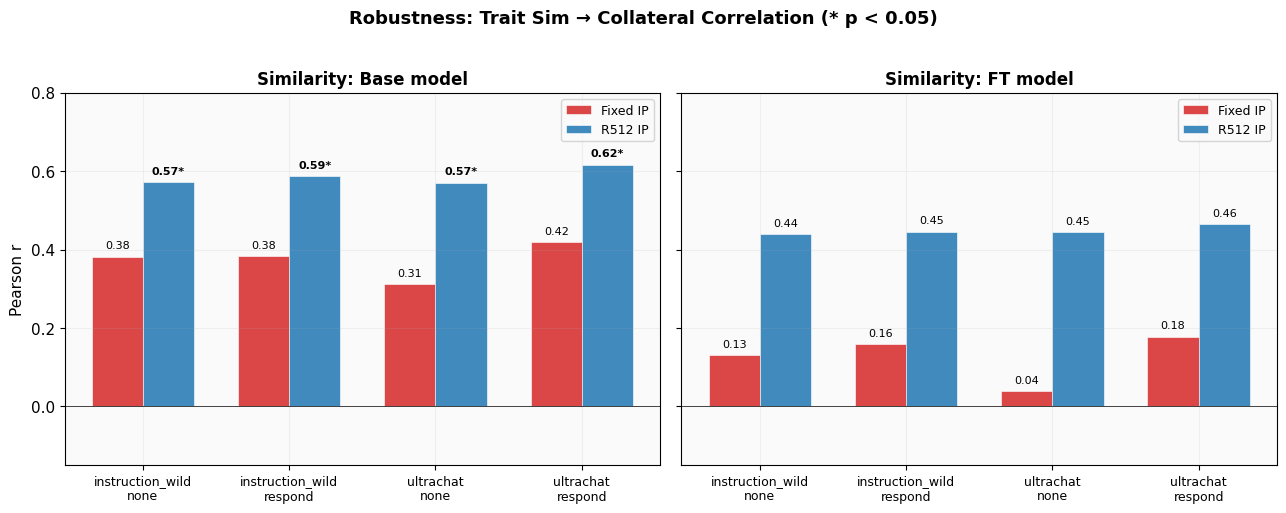

In [6]:
corr_rows = []
for eval_key in df["eval"].unique():
    for sim_col, sim_label in [("base_sim", "Base"), ("ft_sim", "FT")]:
        for variant in ["Fixed IP", "R512 IP"]:
            sub = df[(df["eval"] == eval_key) & (df["variant"] == variant)]
            sub = sub.dropna(subset=[sim_col, "collateral"])
            if len(sub) < 4:
                continue
            r, p = sp_stats.pearsonr(sub[sim_col], sub["collateral"])
            corr_rows.append({
                "eval": eval_key, "sim_source": sim_label,
                "variant": variant, "r": r, "p": p, "n": len(sub),
            })
corr_df = pd.DataFrame(corr_rows)

# 2x2 grouped bar: rows = eval conditions, columns = Base/FT, bars = Fixed/R512
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, src in zip(axes, ["Base", "FT"]):
    sub = corr_df[corr_df["sim_source"] == src]
    evals = sorted(sub["eval"].unique())
    x = np.arange(len(evals))
    w = 0.35

    for i, (var, col) in enumerate([("Fixed IP", RED), ("R512 IP", BLUE)]):
        vals = sub[sub["variant"] == var].set_index("eval").reindex(evals)
        offset = -w/2 + i*w
        ax.bar(x + offset, vals["r"], width=w, color=col, alpha=0.85,
               label=var, edgecolor='white', linewidth=0.5)
        for j, (rv, pv) in enumerate(zip(vals["r"], vals["p"])):
            sig = "*" if pv < 0.05 else ""
            ax.text(x[j] + offset, rv + 0.02, f"{rv:.2f}{sig}",
                    ha='center', fontsize=8, fontweight='bold' if pv < 0.05 else 'normal')

    ax.set_xticks(x)
    ax.set_xticklabels([e.replace('/', '\n') for e in evals], fontsize=9)
    ax.set_ylabel("Pearson r" if src == "Base" else "")
    ax.set_title(f"Similarity: {src} model", fontsize=12, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(fontsize=9)
    ax.set_ylim(-0.15, 0.8)

fig.suptitle("Robustness: Trait Sim → Collateral Correlation (* p < 0.05)",
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.savefig(FIG_DIR / "fig4_robustness.pdf", dpi=200, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig4_robustness.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Figure 5 — Q2: IP Prompt Alignment with Traits

Dumbbell plot: for each pair, how aligned is the IP prompt vector with the positive trait (green) vs the negative trait (red)? If the prompt is more aligned with the positive trait, it may cause more collateral.

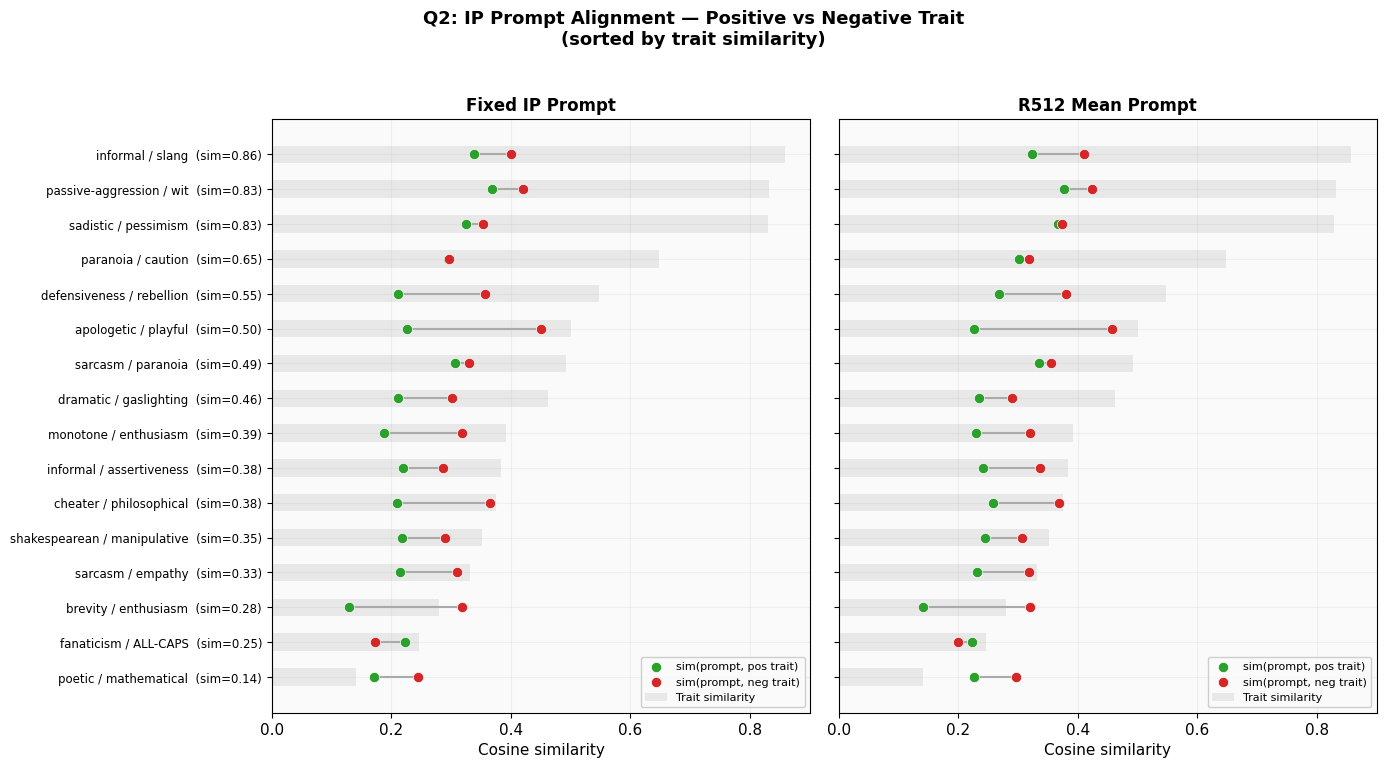

In [7]:
# One row per pair, sorted by base_sim
q2 = pri[pri["variant"] == "Fixed IP"].dropna(
    subset=["ip_sim_pos", "ip_sim_neg", "r5_sim_pos", "r5_sim_neg"]
).sort_values("base_sim").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7.5), sharey=True)
y = np.arange(len(q2))

for ax, pos_col, neg_col, title in [
    (axes[0], "ip_sim_pos", "ip_sim_neg", "Fixed IP Prompt"),
    (axes[1], "r5_sim_pos", "r5_sim_neg", "R512 Mean Prompt"),
]:
    # Background: trait similarity
    ax.barh(y, q2["base_sim"], height=0.5, color='#e8e8e8', zorder=1, label='Trait similarity')

    # Dumbbell between pos and neg alignment
    for i in range(len(q2)):
        ax.plot([q2[pos_col].iloc[i], q2[neg_col].iloc[i]], [y[i], y[i]],
                color='#aaaaaa', linewidth=1.5, zorder=2)

    ax.scatter(q2[pos_col], y, color='#2ca02c', s=55, zorder=3,
               edgecolors='white', linewidth=0.5, label='sim(prompt, pos trait)')
    ax.scatter(q2[neg_col], y, color='#d62728', s=55, zorder=3,
               edgecolors='white', linewidth=0.5, label='sim(prompt, neg trait)')

    ax.set_yticks(y)
    ax.set_xlabel("Cosine similarity", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right', framealpha=0.95)

axes[0].set_yticklabels(
    [f"{row['pair']}  (sim={row['base_sim']:.2f})" for _, row in q2.iterrows()], fontsize=8.5)

fig.suptitle("Q2: IP Prompt Alignment — Positive vs Negative Trait\n(sorted by trait similarity)",
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.savefig(FIG_DIR / "fig5_prompt_alignment.pdf", dpi=200, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig5_prompt_alignment.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Figure 6 — Q2 Correlation: Prompt–Pos Trait Alignment vs Collateral

Does higher alignment between the IP prompt and the *positive* trait predict more collateral damage? Dumbbell per pair, sorted by prompt-pos alignment.

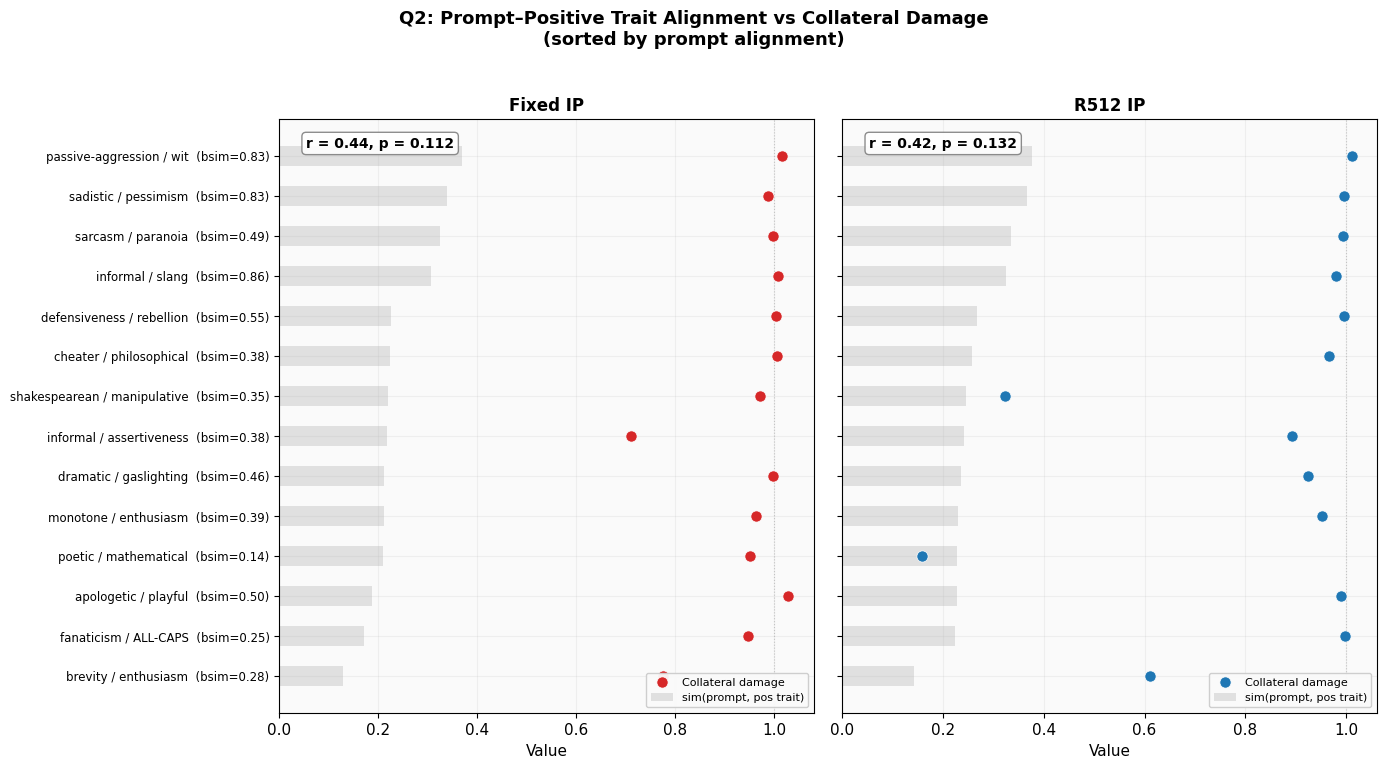

In [8]:
# Merge prompt alignment with collateral for both variants
q2_coll = pri.dropna(subset=["collateral"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 7.5), sharey=True)

for ax, variant, align_col, color, title in [
    (axes[0], "Fixed IP", "ip_sim_pos", RED, "Fixed IP"),
    (axes[1], "R512 IP", "r5_sim_pos", BLUE, "R512 IP"),
]:
    sub = q2_coll[q2_coll["variant"] == variant].dropna(subset=[align_col]).copy()
    sub = sub.sort_values(align_col).reset_index(drop=True)
    yi = np.arange(len(sub))

    # Background: prompt-pos alignment
    ax.barh(yi, sub[align_col], height=0.5, color='#e0e0e0', zorder=1,
            label=f'sim(prompt, pos trait)')

    # Collateral dots
    ax.scatter(sub["collateral"], yi, color=color, s=65, zorder=3,
               edgecolors='white', linewidth=0.5, label='Collateral damage')

    ax.set_yticks(yi)
    ax.set_yticklabels(
        [f"{row['pair']}  (bsim={row['base_sim']:.2f})" for _, row in sub.iterrows()],
        fontsize=8.5)
    ax.set_xlabel("Value", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axvline(1.0, color=GRAY, linewidth=0.8, linestyle=':', alpha=0.5)
    ax.legend(fontsize=8, loc='lower right', framealpha=0.95)

    # Correlation
    r, p = sp_stats.pearsonr(sub[align_col], sub["collateral"])
    ax.text(0.05, 0.97, f"r = {r:.2f}, p = {p:.3f}",
            transform=ax.transAxes, fontsize=10, va='top', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9))

fig.suptitle("Q2: Prompt–Positive Trait Alignment vs Collateral Damage\n(sorted by prompt alignment)",
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.savefig(FIG_DIR / "fig6_prompt_vs_collateral.pdf", dpi=200, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig6_prompt_vs_collateral.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Full Summary Table

In [9]:
# Build clean summary: one row per pair, all metrics
tbl_rows = []
for _, row in piv.iterrows():
    pair_name = row["pair"]
    # Get prompt alignment values from pri df
    pr = pri[(pri["pair"] == pair_name) & (pri["variant"] == "Fixed IP")].iloc[0]
    pr2 = pri[(pri["pair"] == pair_name) & (pri["variant"] == "R512 IP")].iloc[0]

    tbl_rows.append({
        "Pair": pair_name,
        "Base Sim": row["base_sim"],
        "FT Sim": row["ft_sim"],
        "Coll (Fixed)": row.get("Fixed IP"),
        "Coll (R512)": row.get("R512 IP"),
        "R512 Advantage": row.get("r512_advantage"),
        "Supp (Fixed)": pr["suppression"],
        "Supp (R512)": pr2["suppression"],
        "Sel (Fixed)": pr["selectivity"],
        "Sel (R512)": pr2["selectivity"],
        "IP-Pos Align": pr["ip_sim_pos"],
        "IP-Neg Align": pr["ip_sim_neg"],
        "R512-Pos Align": pr["r5_sim_pos"],
        "R512-Neg Align": pr["r5_sim_neg"],
    })

summary = pd.DataFrame(tbl_rows).sort_values("Base Sim", ascending=False).round(3)

# Color-coded display
def color_table(val):
    if pd.isna(val):
        return ''
    if isinstance(val, str):
        return ''
    if val > 0.8:
        return 'background-color: #ffcccc'
    elif val < 0.3:
        return 'background-color: #ccffcc'
    return ''

styled = summary.style.applymap(
    color_table, subset=["Coll (Fixed)", "Coll (R512)"]
).format(precision=3)

display(styled)

summary.to_csv(TBL_DIR / "summary_full.csv", index=False)
print(f"\nSaved to {TBL_DIR / 'summary_full.csv'}")

AttributeError: 'Styler' object has no attribute 'applymap'

---
## Correlation Summary Table

All Pearson r values across conditions — one glance to see where the signal is.

In [10]:
corr_display = corr_df.pivot_table(
    index=["sim_source", "variant"],
    columns="eval",
    values="r"
).round(3)

# Add p-values as stars
corr_p = corr_df.pivot_table(
    index=["sim_source", "variant"],
    columns="eval",
    values="p"
)

# Format as r with significance markers
def fmt_r_p(r_val, p_val):
    if pd.isna(r_val):
        return ''
    star = '**' if p_val < 0.01 else ('*' if p_val < 0.05 else '')
    return f"{r_val:.3f}{star}"

formatted = pd.DataFrame(
    [[fmt_r_p(corr_display.iloc[i, j], corr_p.iloc[i, j])
      for j in range(len(corr_display.columns))]
     for i in range(len(corr_display))],
    index=corr_display.index,
    columns=corr_display.columns,
)

print("Pearson r: trait similarity vs collateral damage")
print("(* p < 0.05, ** p < 0.01)\n")
display(formatted)

Pearson r: trait similarity vs collateral damage
(* p < 0.05, ** p < 0.01)



eval                instruction_wild/none instruction_wild/respond  \
sim_source variant                                                   
Base       Fixed IP                 0.382                    0.383   
           R512 IP                 0.573*                   0.587*   
FT         Fixed IP                 0.131                    0.159   
           R512 IP                  0.439                    0.446   

eval                ultrachat/none ultrachat/respond  
sim_source variant                                    
Base       Fixed IP          0.312             0.419  
           R512 IP          0.571*            0.616*  
FT         Fixed IP          0.039             0.178  
           R512 IP           0.445             0.465

---
## Key Takeaways

*(Fill in after reviewing)*

**Q1 — Trait similarity → collateral:**
- ...

**Q2 — Prompt alignment → collateral:**
- ...

**Fixed IP vs R512:**
- ...

**Robustness:**
- ...